<a href="https://colab.research.google.com/github/Nolan-Jgr/golf-analytics-project/blob/main/notebooks/02_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf Analytics Project


## Phase 2: Exploratory Data Analysis

### **Project Overview**
This notebook explores the cleaned golf performance dataset to identify
patterns, relationships, and trends in player performance.

The analysis focuses on scoring, driving, putting, greens in regulation,
birdies, bogeys, strokes gained, tournament performance, and earnings.

The primary objectives are to:

- Understand the overall distribution of player performance
- Compare player performance
- Identify factors associated with lower scores
- Analyze relationships between golf performance metrics
- Compare tournament and course difficulty
- Examine the relationship between performance and earnings
- Develop actionable insights for later dashboard and predictive modeling

### **Import Libraries and Load Dataset**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Fictional_Golf_Project/Data/Fictional_Golf_Dataset_25000_Realistic_Cleaned.csv")
df.head()

,PlayerID,FirstName,LastName,Age,Tournament,Course,Season,Round,Date,CoursePar,DriveDistance,FairwaysHit,GIR,Putts,Birdies,Bogeys,Score,StrokesGainedTotal,Earnings,ScoreToPar,BirdiePct,BogeyPct,EarningsPerStroke
0,218,Ethan,Jackson,35,Highland Invitational,Highland National,2025,1,2025-04-12,70,283.2,10,14,31,4,4,73,-0.43,17602.99,3,0.222222,0.222222,241.136849
1,452,Tyler,Brown,35,Lakeview Championship,Lakeview Resort,2025,4,2025-04-01,72,312.0,12,14,28,9,4,68,1.54,10919.02,-4,0.500000,0.222222,160.573824
2,418,Ethan,Smith,25,Cedar Hills Classic,Cedar Hills Golf Club,2025,1,2025-04-26,71,300.6,8,12,35,5,5,68,-0.29,16697.88,-3,0.277778,0.277778,245.557059
3,411,Ryan,Smith,20,Riverbend Open,Riverbend Country Club,2025,1,2025-05-24,71,286.0,7,11,31,6,1,67,-0.04,17070.76,-4,0.333333,0.055556,254.787463
4,5,Cameron,Smith,26,Mountain Invitational,Mountain Creek,2025,3,2025-06-09,72,265.0,9,13,31,5,3,73,0.71,8371.10,1,0.277778,0.166667,114.672603


In [4]:
df.shape

(25000, 23)

### **Dataset Overview**

In [5]:
df.describe()

,PlayerID,Age,Season,Round,CoursePar,DriveDistance,FairwaysHit,GIR,Putts,Birdies,Bogeys,Score,StrokesGainedTotal,Earnings,ScoreToPar,BirdiePct,BogeyPct,EarningsPerStroke
count,25000.000000,25000.000000,25000.0,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,250.297440,31.111720,2025.0,2.504880,71.333480,295.246208,8.993000,12.012480,30.00004,4.022440,3.000600,71.529400,-0.000503,11646.325822,0.195920,0.223469,0.166700,166.986708
std,144.337087,8.108619,0.0,1.118046,0.744992,17.780500,2.292047,2.379057,2.58814,1.976546,1.533354,3.622703,1.593461,6499.214142,3.556723,0.109808,0.085186,98.995899
min,1.000000,18.000000,2025.0,1.000000,70.000000,225.000000,4.000000,6.000000,23.00000,0.000000,0.000000,60.000000,-5.000000,0.000000,-12.000000,0.000000,0.000000,0.000000
25%,125.000000,24.000000,2025.0,2.000000,71.000000,283.200000,7.000000,10.000000,28.00000,3.000000,2.000000,69.000000,-1.080000,6931.352500,-2.000000,0.166667,0.111111,94.381581
50%,250.000000,31.000000,2025.0,3.000000,71.000000,295.200000,9.000000,12.000000,30.00000,4.000000,3.000000,72.000000,-0.000000,11545.855000,0.000000,0.222222,0.166667,161.294662
75%,375.000000,38.000000,2025.0,4.000000,72.000000,307.200000,11.000000,14.000000,32.00000,5.000000,4.000000,74.000000,1.070000,16064.747500,3.000000,0.277778,0.222222,231.253034
max,500.000000,45.000000,2025.0,4.000000,72.000000,371.900000,14.000000,18.000000,38.00000,10.000000,7.000000,85.000000,5.000000,35555.350000,13.000000,0.555556,0.388889,582.853333


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PlayerID,25000.0,250.297440,144.337087,1.0,125.000000,250.000000,375.000000,500.000000
Age,25000.0,31.111720,8.108619,18.0,24.000000,31.000000,38.000000,45.000000
Season,25000.0,2025.000000,0.000000,2025.0,2025.000000,2025.000000,2025.000000,2025.000000
Round,25000.0,2.504880,1.118046,1.0,2.000000,3.000000,4.000000,4.000000
CoursePar,25000.0,71.333480,0.744992,70.0,71.000000,71.000000,72.000000,72.000000
DriveDistance,25000.0,295.246208,17.780500,225.0,283.200000,295.200000,307.200000,371.900000
FairwaysHit,25000.0,8.993000,2.292047,4.0,7.000000,9.000000,11.000000,14.000000
GIR,25000.0,12.012480,2.379057,6.0,10.000000,12.000000,14.000000,18.000000
Putts,25000.0,30.000040,2.588140,23.0,28.000000,30.000000,32.000000,38.000000
Birdies,25000.0,4.022440,1.976546,0.0,3.000000,4.000000,5.000000,10.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PlayerID            25000 non-null  int64  
 1   FirstName           25000 non-null  object 
 2   LastName            25000 non-null  object 
 3   Age                 25000 non-null  int64  
 4   Tournament          25000 non-null  object 
 5   Course              25000 non-null  object 
 6   Season              25000 non-null  int64  
 7   Round               25000 non-null  int64  
 8   Date                25000 non-null  object 
 9   CoursePar           25000 non-null  int64  
 10  DriveDistance       25000 non-null  float64
 11  FairwaysHit         25000 non-null  int64  
 12  GIR                 25000 non-null  int64  
 13  Putts               25000 non-null  int64  
 14  Birdies             25000 non-null  int64  
 15  Bogeys              25000 non-null  int64  
 16  Scor

In [8]:
df.nunique()

,0
PlayerID,500
FirstName,20
LastName,20
Age,28
Tournament,12
Course,12
Season,1
Round,4
Date,48
CoursePar,3


### **Overall Performance KPIs**


This section summarizes the overall performance of players across all
observations in the dataset.

In [9]:
print("Average Score:", round(df["Score"].mean(),2))
print("Average Score to Par:", round(df["ScoreToPar"].mean(), 2))
print("Average Driving Distance:", round(df["DriveDistance"].mean(), 2))
print("Average Fairways Hit:", round(df["FairwaysHit"].mean(), 2))
print("Average Putts:", round(df["Putts"].mean(), 2))
print("Average GIR:", round(df["GIR"].mean(), 2))
print("Average Birdies:", round(df["Birdies"].mean(), 2))
print("Average Bogeys:", round(df["Bogeys"].mean(), 2))
print("Average Earnings:", round(df["Earnings"].mean(), 2))
print("Average Strokes Gained:", round(df["StrokesGainedTotal"].mean(), 2))

Average Score: 71.53
Average Score to Par: 0.2
Average Driving Distance: 295.25
Average Fairways Hit: 8.99
Average Putts: 30.0
Average GIR: 12.01
Average Birdies: 4.02
Average Bogeys: 3.0
Average Earnings: 11646.33
Average Strokes Gained: -0.0


In [10]:
fairway_percentage = (df["FairwaysHit"].mean() / 14) * 100

gir_percentage = (df["GIR"].mean() / 18) * 100

print("Average Fairway Percentage:", round(fairway_percentage, 2), "%")
print("Average GIR Percentage:", round(gir_percentage, 2), "%")

Average Fairway Percentage: 64.24 %
Average GIR Percentage: 66.74 %


### **Player Performance**

Who *are* the best-performing players?

Player-level performance is analyzed by aggregating round-level observations
for each player. This allows consistent comparison of scoring, driving,
putting, GIR, birdies, bogeys, strokes gained, and earnings.

In [11]:
player_summary = (
    df.groupby(["PlayerID","FirstName", "LastName"])
      .agg(
          AverageScore = ("Score", "mean"),
          AverageScoreToPar = ("ScoreToPar", "mean"),
          AverageDrivingDistance = ("DriveDistance", "mean"),
          AveragePutts = ("Putts", "mean"),
          AverageGIR = ("GIR", "mean"),
          AverageBirdies = ("Birdies", "mean"),
          AverageBogeys = ("Bogeys", "mean"),
          AverageStrokesGained = ("StrokesGainedTotal", "mean"),
          TotalEarnings = ("Earnings", "sum"),
          RoundsPlayed = ("Score", "count")
      )
      .reset_index()
)

In [12]:
player_summary.head()

,PlayerID,FirstName,LastName,AverageScore,AverageScoreToPar,AverageDrivingDistance,AveragePutts,AverageGIR,AverageBirdies,AverageBogeys,AverageStrokesGained,TotalEarnings,RoundsPlayed
0,1,Alex,Smith,70.204082,-1.122449,300.381633,30.142857,12.448980,4.510204,2.510204,0.575306,670835.03,49
1,2,Jordan,Smith,71.714286,0.367347,291.936735,29.755102,12.102041,4.020408,3.346939,0.115102,580298.38,49
2,3,Taylor,Smith,69.880000,-1.460000,304.258000,29.660000,12.760000,4.660000,2.500000,0.753200,735088.82,50
3,4,Morgan,Smith,67.612245,-3.714286,309.463265,28.755102,14.000000,5.632653,1.734694,2.187551,889623.94,49
4,5,Cameron,Smith,72.392157,1.078431,290.858824,29.686275,11.843137,3.627451,3.431373,-0.002941,548687.50,51


In [13]:
top_players = (
    player_summary
    .sort_values("AverageScore")
    .head(10)
)

top_players[
    ["FirstName","LastName","AverageScore","AverageGIR",
     "AverageBirdies","AverageBogeys","AverageStrokesGained"]
]

,FirstName,LastName,AverageScore,AverageGIR,AverageBirdies,AverageBogeys,AverageStrokesGained
478,Mason,Davis,64.269231,15.519231,7.211538,0.538462,3.082885
252,Logan,Harris,64.734694,15.265306,6.795918,0.816327,2.711837
209,Jamie,Jackson,64.880000,15.360000,6.940000,0.980000,3.094800
220,Alex,White,64.886792,15.132075,6.566038,0.962264,2.804906
179,Luke,Anderson,65.153846,15.461538,7.038462,1.000000,3.097500
113,Blake,Wilson,65.176471,15.000000,6.921569,0.921569,3.243725
125,Drew,Moore,65.220000,14.660000,6.680000,1.120000,2.956000
378,Mason,Clark,65.320000,14.840000,6.720000,1.100000,2.359200
284,Cameron,Thompson,65.647059,14.725490,6.411765,1.019608,2.741569
420,Alex,Johnson,65.764706,14.411765,6.450980,1.607843,2.696471


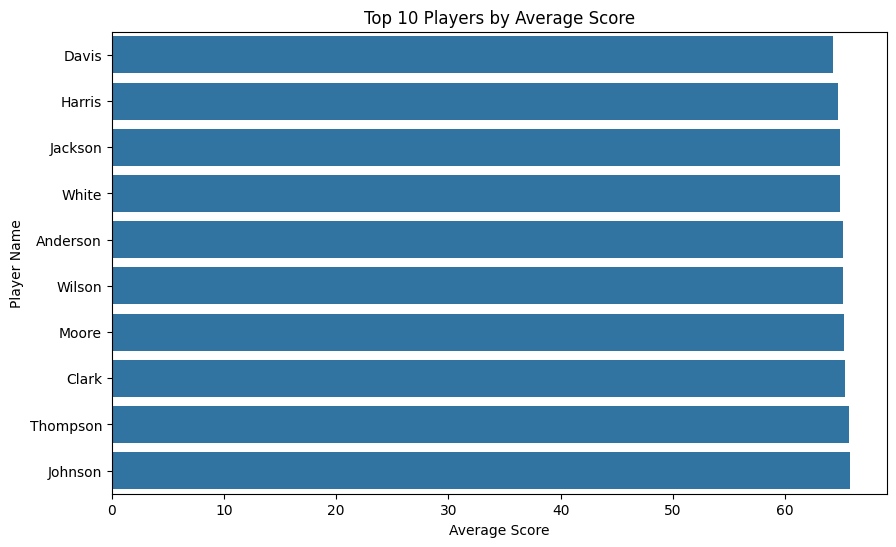

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_players,
    x = "AverageScore",
    y = "LastName"
)

plt.title("Top 10 Players by Average Score")
plt.xlabel("Average Score")
plt.ylabel("Player Name")
plt.show()

>The top 10 players have relatively similar average scores, with the best player averaging around 64 and the remaining players clustered in the mid-60s. This suggests that performance among the highest-performing players is fairly competitive, with relatively small differences in average scoring.

The hightest-performing players demonstrate lower average strokes through their high GIR, birdie production, and bogey avoidance.

### **Scoring Analysis**

#### Score Distribution

Scoring distributions are examined to understand the range and consistency
of performance across the dataset.

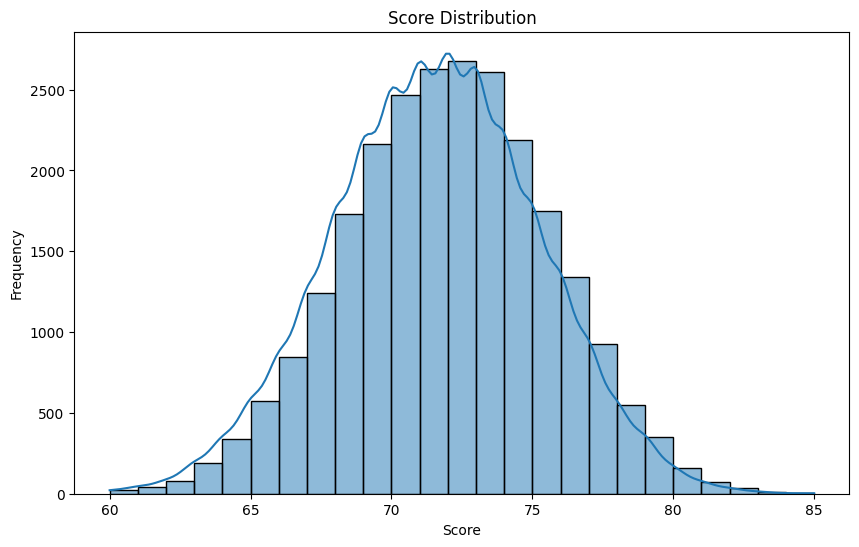

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Score"], bins=25, kde=True)

plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

>Scores are approximately normally distributed, with most rounds falling between 68 and 76 strokes and the highest concentration around 72–73. The distribution ranges from roughly 60 to 85, indicating meaningful variation in round-to-round performance.

#### Score to Par Distribution

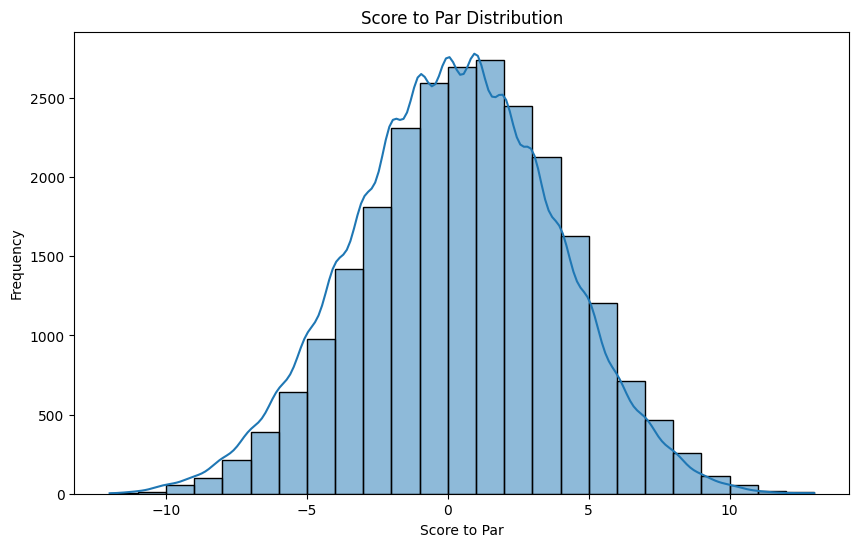

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(df["ScoreToPar"], bins=25, kde=True)

plt.title("Score to Par Distribution")
plt.xlabel("Score to Par")
plt.ylabel("Frequency")
plt.show()

>Score to par is centered close to even par, with most rounds falling between approximately -5 and +6. The relatively balanced distribution around zero indicates that the dataset contains a mix of under-par, even-par, and over-par rounds.

### **Driving Analysis**

#### Driving Distance vs Score

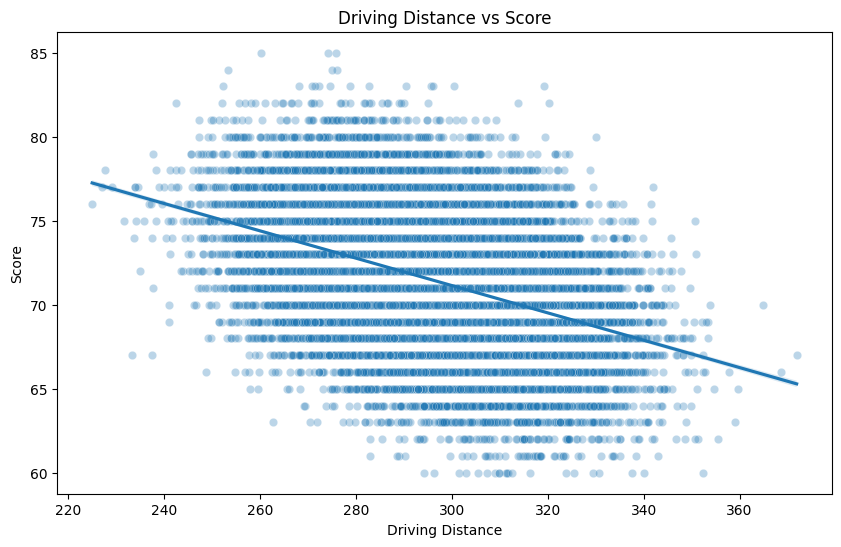

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="DriveDistance", y="Score", alpha=0.3)

sns.regplot(data=df,x="DriveDistance",y="Score",scatter=False)

plt.title("Driving Distance vs Score")
plt.xlabel("Driving Distance")
plt.ylabel("Score")
plt.show()

>There is a moderate negative relationship between driving distance and score. The trend line slopes downward, indicating that longer driving distances are generally associated with lower scores in the dataset. However, the substantial spread of points shows that distance alone does not determine scoring performance.

#### Fairways Hit vs Score

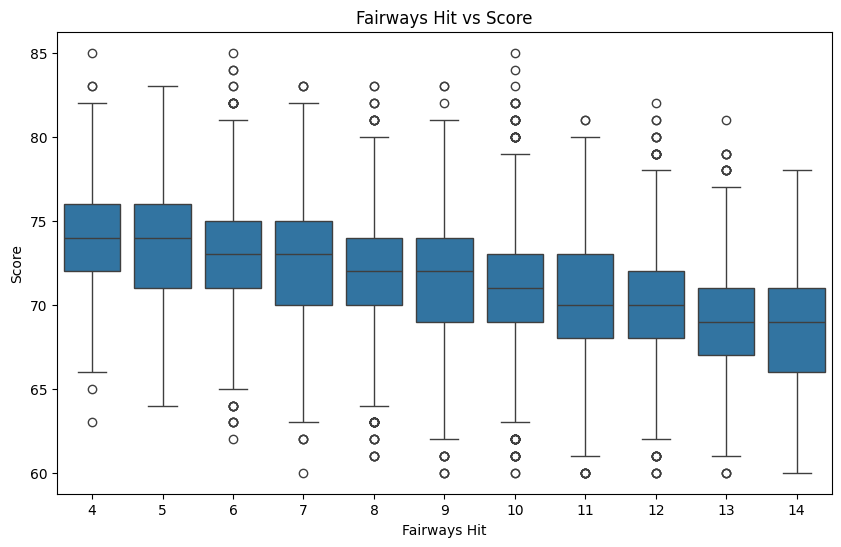

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="FairwaysHit", y="Score")

plt.title("Fairways Hit vs Score")
plt.xlabel("Fairways Hit")
plt.ylabel("Score")
plt.show()

>The boxplot shows a general downward trend in average scores as the number of fairways hit increases. Players hitting more fairways tend to record lower scores, although there is considerable overlap between groups. This suggests that driving accuracy has a relationship with scoring but is not the only factor involved.

### **Putting Analysis**

#### Putts vs Score

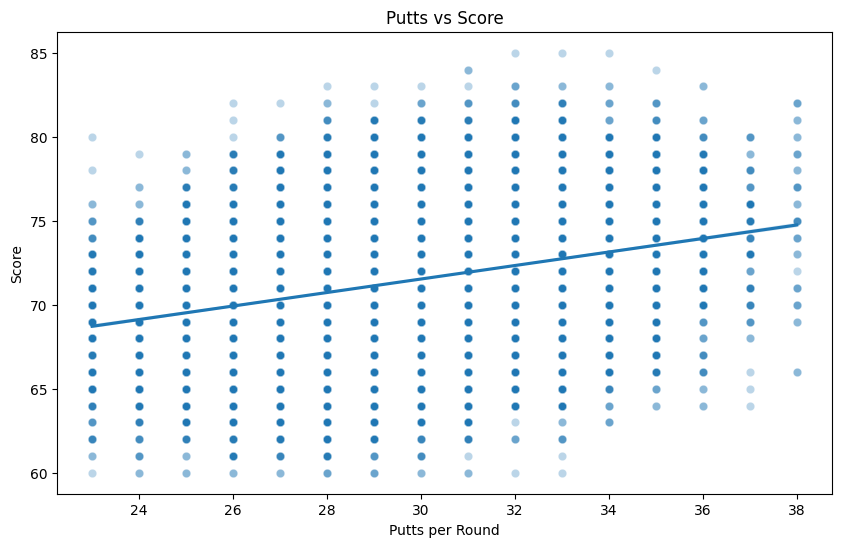

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Putts", y="Score", alpha=0.3)

sns.regplot(data=df,x="Putts",y="Score",scatter=False)

plt.title("Putts vs Score")
plt.xlabel("Putts per Round")
plt.ylabel("Score")
plt.show()

>There is a positive relationship between putts and score. Rounds with more putts generally have higher scores, suggesting that putting performance is associated with overall scoring. However, the wide spread at each putting level indicates that other aspects of the game also contribute substantially to score.

### **GIR Analysis**

#### GIR vs Score

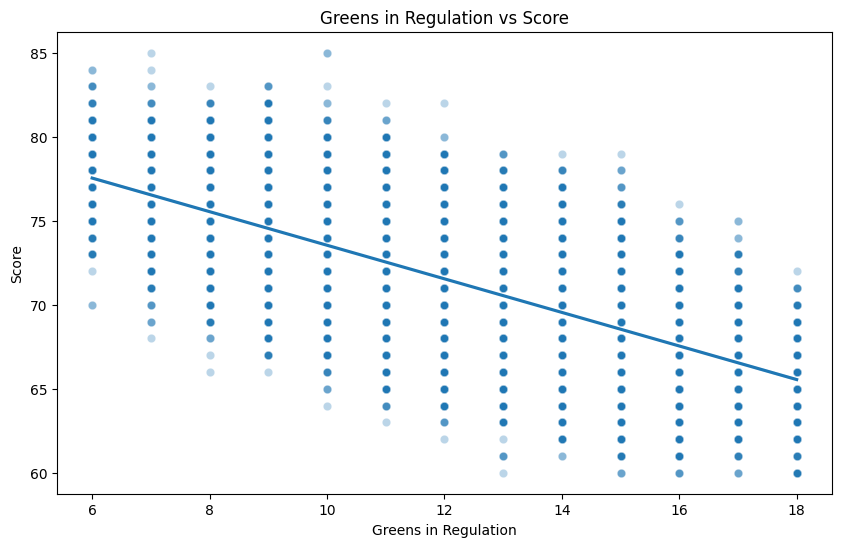

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="GIR", y="Score", alpha=0.3)

sns.regplot(data=df,x="GIR",y="Score",scatter=False)

plt.title("Greens in Regulation vs Score")
plt.xlabel("Greens in Regulation")
plt.ylabel("Score")
plt.show()

>GIR shows a strong negative relationship with score. As the number of greens hit in regulation increases, average scores generally decrease. This indicates that approach-shot performance and the ability to reach greens in regulation are strongly associated with lower scores in the dataset.

In [21]:
df["GIR_group"] = pd.cut(
    df["GIR"],
    bins=[0,6,9,12,15,18],
    labels=["0-6","7-9","10-12","13-15","16-18"]
)

gir_summary = (
    df.groupby("GIR_group",observed=True)["Score"]
    .mean()
    .reset_index()
)

gir_summary

,GIR_group,Score
0,0-6,77.537849
1,7-9,75.091308
2,10-12,72.446031
3,13-15,69.722796
4,16-18,67.005006


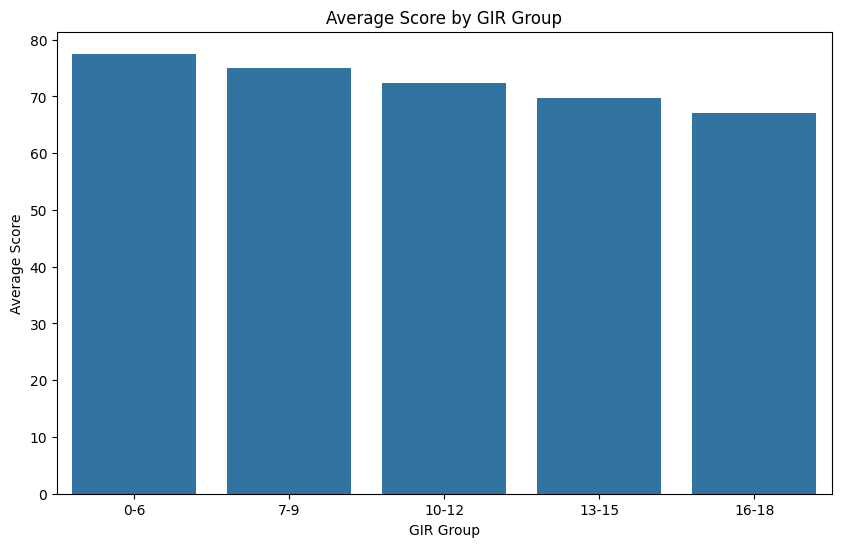

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(data=gir_summary, x="GIR_group", y="Score")

plt.title("Average Score by GIR Group")
plt.xlabel("GIR Group")
plt.ylabel("Average Score")
plt.show()

>The grouped analysis reinforces the previous finding. Average score decreases consistently as GIR increases, falling from approximately 77.5 strokes for the lowest GIR group to about 67 strokes for the 16–18 GIR group. This provides a clear indication that higher GIR performance is associated with substantially lower scoring.

### **Birdie/Bogey Analysis**

#### Birdies vs Score

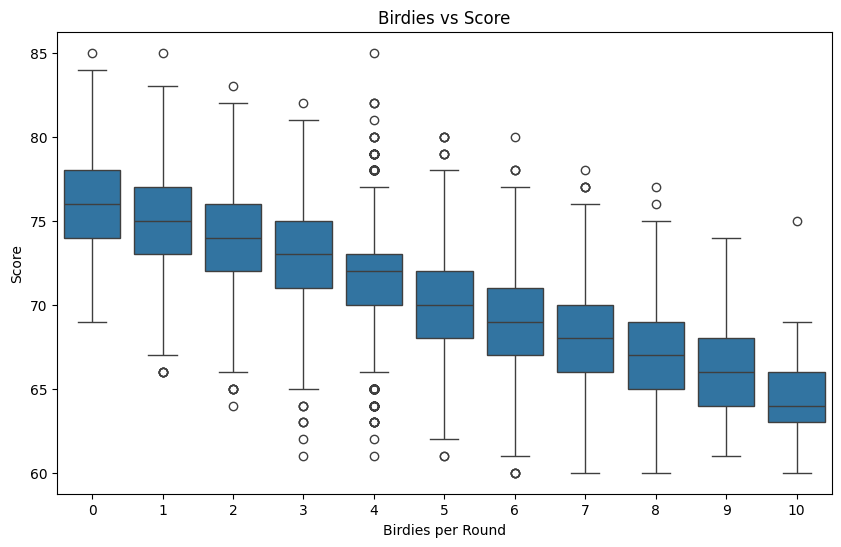

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="Birdies", y="Score")

plt.title("Birdies vs Score")
plt.xlabel("Birdies per Round")
plt.ylabel("Score")
plt.show()

>There is a clear negative relationship between birdie production and score. Players making more birdies generally record lower scores, with the median score declining as birdies per round increase. This suggests that the ability to generate birdie opportunities and convert them is strongly associated with better scoring.

#### Bogeys vs Score

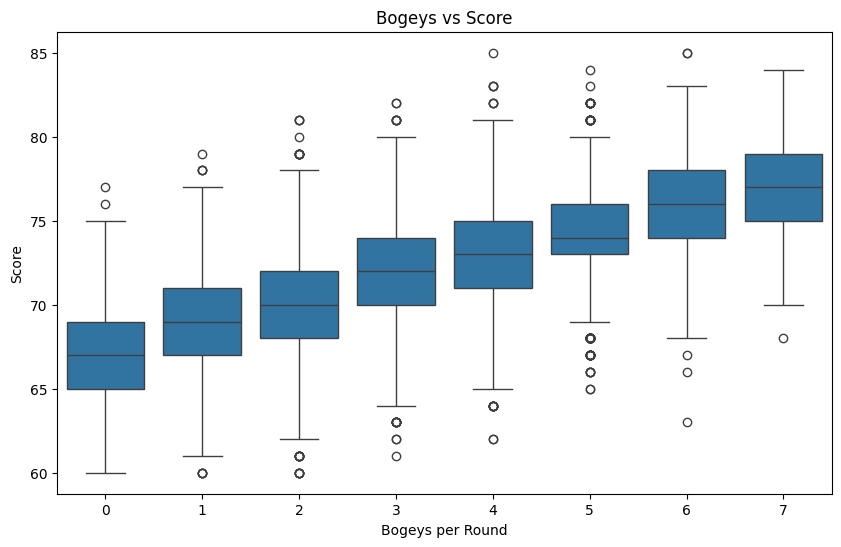

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="Bogeys", y="Score")

plt.title("Bogeys vs Score")
plt.xlabel("Bogeys per Round")
plt.ylabel("Score")
plt.show()

>Bogeys show the opposite pattern. Average scores generally increase as the number of bogeys increases, with rounds containing more bogeys producing higher scores. This indicates that avoiding bogeys is an important component of maintaining lower scores.

#### Birdie vs Bogey Comparison

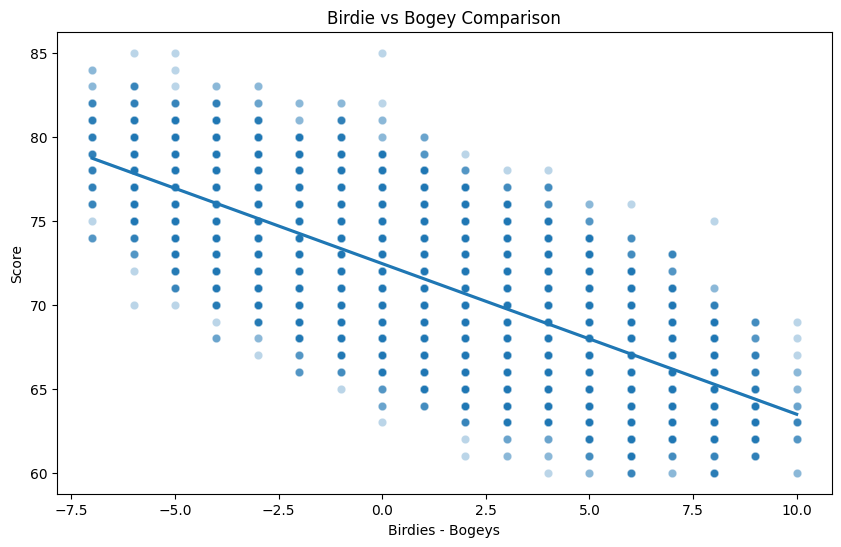

In [25]:
df["BirdieBogeyBalance"] = df["Birdies"] - df["Bogeys"]

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="BirdieBogeyBalance", y="Score",alpha=0.3)

sns.regplot(data=df,x="BirdieBogeyBalance",y="Score",scatter=False)

plt.title("Birdie vs Bogey Comparison")
plt.xlabel("Birdies - Bogeys")
plt.ylabel("Score")
plt.show()

>The birdie-bogey balance has a strong negative relationship with score. As the difference between birdies and bogeys increases, scores generally decrease. This suggests that producing more birdies relative to bogeys is associated with stronger overall scoring performance.

### **Strokes Gained Analysis**

#### Strokes Gained vs Score

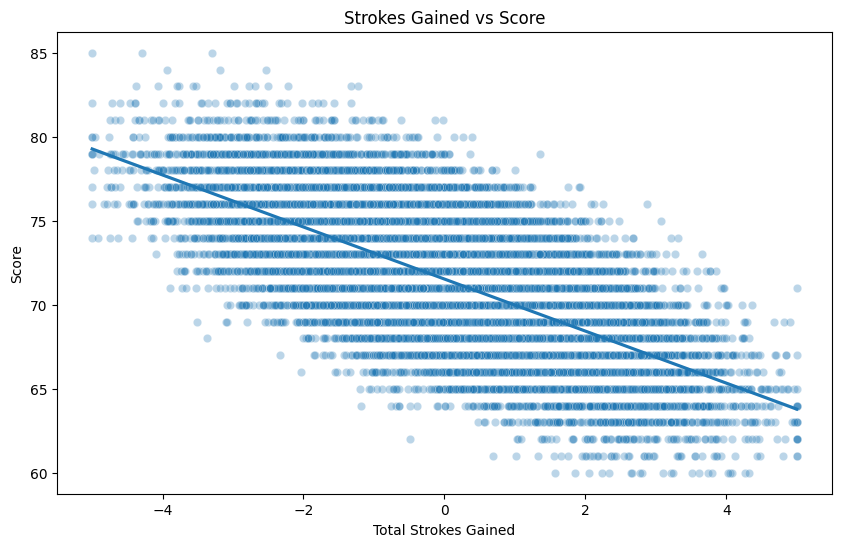

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x="StrokesGainedTotal", y="Score",alpha=0.3)

sns.regplot(data=df,x="StrokesGainedTotal",y="Score",scatter=False)

plt.title("Strokes Gained vs Score")
plt.xlabel("Total Strokes Gained")
plt.ylabel("Score")
plt.show()

>Strokes Gained Total has a strong negative relationship with score. Players who gain more strokes generally record lower scores, while negative strokes gained is associated with higher scores. This makes strokes gained one of the clearest indicators of overall performance in the dataset.

In [27]:
player_summary.sort_values(
    "AverageStrokesGained",
    ascending=False
).head(10)

,PlayerID,FirstName,LastName,AverageScore,AverageScoreToPar,AverageDrivingDistance,AveragePutts,AverageGIR,AverageBirdies,AverageBogeys,AverageStrokesGained,TotalEarnings,RoundsPlayed
113,114,Blake,Wilson,65.176471,-6.176471,317.900000,28.156863,15.000000,6.921569,0.921569,3.243725,1179640.94,51
179,180,Luke,Anderson,65.153846,-6.211538,320.015385,28.769231,15.461538,7.038462,1.000000,3.097500,1213826.53,52
209,210,Jamie,Jackson,64.880000,-6.460000,318.198000,28.080000,15.360000,6.940000,0.980000,3.094800,1200723.61,50
478,479,Mason,Davis,64.269231,-7.057692,322.817308,28.519231,15.519231,7.211538,0.538462,3.082885,1258863.59,52
125,126,Drew,Moore,65.220000,-6.140000,318.538000,28.460000,14.660000,6.680000,1.120000,2.956000,1134027.07,50
323,324,Morgan,Martinez,65.820000,-5.500000,319.608000,28.300000,14.620000,6.800000,1.140000,2.833600,1096722.42,50
220,221,Alex,White,64.886792,-6.471698,320.866038,28.132075,15.132075,6.566038,0.962264,2.804906,1195463.39,53
284,285,Cameron,Thompson,65.647059,-5.686275,314.072549,28.235294,14.725490,6.411765,1.019608,2.741569,1102251.11,51
252,253,Logan,Harris,64.734694,-6.591837,313.685714,28.387755,15.265306,6.795918,0.816327,2.711837,1120674.32,49
420,421,Alex,Johnson,65.764706,-5.568627,317.031373,28.588235,14.411765,6.450980,1.607843,2.696471,1065519.09,51


In [28]:
player_summary.sort_values(
    "AverageStrokesGained",
    ascending=True
).head(10)

,PlayerID,FirstName,LastName,AverageScore,AverageScoreToPar,AverageDrivingDistance,AveragePutts,AverageGIR,AverageBirdies,AverageBogeys,AverageStrokesGained,TotalEarnings,RoundsPlayed
74,75,Avery,Davis,78.480000,7.160000,268.332000,31.660000,8.700000,1.160000,5.720000,-3.149400,80044.67,50
262,263,Taylor,Martin,78.306122,6.959184,275.010204,31.387755,8.469388,1.183673,5.224490,-2.994286,90818.47,49
471,472,Tyler,Davis,78.100000,6.800000,272.566000,31.300000,8.680000,0.900000,5.140000,-2.988800,100061.61,50
382,383,Taylor,Lewis,77.450980,6.156863,272.935294,31.627451,9.156863,1.411765,4.980392,-2.777647,118267.38,51
442,443,Taylor,Brown,77.163265,5.857143,277.363265,31.489796,8.918367,1.387755,4.755102,-2.644082,130702.97,49
285,286,Drew,Thompson,77.240000,5.880000,275.580000,31.580000,9.380000,1.640000,4.880000,-2.623000,140066.09,50
431,432,Tyler,Johnson,77.640000,6.300000,273.696000,31.740000,9.220000,1.260000,5.260000,-2.616800,91990.66,50
236,237,Cole,White,77.039216,5.725490,272.960784,30.764706,9.705882,1.647059,4.960784,-2.575882,167208.35,51
37,38,Ethan,Johnson,77.306122,5.959184,275.393878,31.591837,9.448980,1.530612,4.857143,-2.520000,124207.41,49
110,111,Ryan,Wilson,76.764706,5.470588,279.360784,31.352941,9.549020,1.647059,4.803922,-2.437059,169849.75,51


### **Tournament & Course Analysis**

Tournament-level analysis examines differences in scoring and performance
across the courses in the dataset.

In [29]:
tournament_summary = (
    df.groupby(["Tournament","Course"])
      .agg(
        AverageScore = ("Score", "mean"),
        AverageScoreToPar = ("ScoreToPar", "mean"),
        AverageDrivingDistance = ("DriveDistance", "mean"),
        AveragePutts = ("Putts", "mean"),
        AverageGIR = ("GIR", "mean"),
        AverageBirdies = ("Birdies", "mean"),
        AverageBoges = ("Bogeys", "mean"),
        AverageStrokesGained = ("StrokesGainedTotal", "mean"),
        TotalEarnings = ("Earnings", "sum")
    )
    .reset_index()
)
tournament_summary.sort_values("AverageScore")


,Tournament,Course,AverageScore,AverageScoreToPar,AverageDrivingDistance,AveragePutts,AverageGIR,AverageBirdies,AverageBoges,AverageStrokesGained,TotalEarnings
4,Grand Lakes Championship,Grand Lakes Golf Club,70.340038,0.340038,295.768678,30.000479,11.997605,4.014847,3.003352,0.016662,25137512.36
5,Highland Invitational,Highland National,70.608402,0.608402,294.969532,30.006760,11.937228,3.996137,3.045872,0.010000,21897034.11
10,Riverbend Open,Riverbend Country Club,70.877277,-0.122723,294.979386,29.953020,11.978907,3.996165,3.046021,0.014698,25376889.39
11,Southern Classic,Southern Pines,70.908349,-0.091651,294.908829,29.964491,12.010557,4.004798,3.009597,-0.020120,26947556.99
1,Cedar Hills Classic,Cedar Hills Golf Club,71.118636,0.118636,295.362248,30.043228,12.037464,4.056196,2.975504,0.009774,23696088.10
8,Oak Valley Open,Oak Valley Country Club,71.258481,0.258481,295.649976,29.957477,12.019589,4.038700,2.980889,-0.012097,22027035.24
6,Lakeview Championship,Lakeview Resort,71.817349,-0.182651,294.965590,30.145542,12.021687,4.009157,3.016867,-0.004978,23228735.90
9,Pine Ridge Classic,Pine Ridge Golf Club,71.951231,-0.048769,295.437422,29.985031,12.114437,4.066152,2.984549,-0.003646,21884878.20
0,Autumn Masters,Autumn Hills,72.140124,0.140124,294.637829,29.930177,12.066954,4.040650,2.999522,0.001731,26361981.45
3,Coastal Cup,Coastal Dunes,72.337476,0.337476,295.595889,30.010038,11.951721,3.991396,3.002390,-0.049852,23835306.43


In [30]:
tournament_summary.sort_values("AverageScore",ascending=False).head(10)

,Tournament,Course,AverageScore,AverageScoreToPar,AverageDrivingDistance,AveragePutts,AverageGIR,AverageBirdies,AverageBoges,AverageStrokesGained,TotalEarnings
7,Mountain Invitational,Mountain Creek,72.637709,0.637709,295.487637,30.042482,11.983771,4.028162,2.957995,0.013150,24201663.39
2,Champions Cup,Champions National,72.353282,0.353282,295.186438,29.962355,12.030405,4.027027,2.985039,0.018900,26563463.99
3,Coastal Cup,Coastal Dunes,72.337476,0.337476,295.595889,30.010038,11.951721,3.991396,3.002390,-0.049852,23835306.43
0,Autumn Masters,Autumn Hills,72.140124,0.140124,294.637829,29.930177,12.066954,4.040650,2.999522,0.001731,26361981.45
9,Pine Ridge Classic,Pine Ridge Golf Club,71.951231,-0.048769,295.437422,29.985031,12.114437,4.066152,2.984549,-0.003646,21884878.20
6,Lakeview Championship,Lakeview Resort,71.817349,-0.182651,294.965590,30.145542,12.021687,4.009157,3.016867,-0.004978,23228735.90
8,Oak Valley Open,Oak Valley Country Club,71.258481,0.258481,295.649976,29.957477,12.019589,4.038700,2.980889,-0.012097,22027035.24
1,Cedar Hills Classic,Cedar Hills Golf Club,71.118636,0.118636,295.362248,30.043228,12.037464,4.056196,2.975504,0.009774,23696088.10
11,Southern Classic,Southern Pines,70.908349,-0.091651,294.908829,29.964491,12.010557,4.004798,3.009597,-0.020120,26947556.99
10,Riverbend Open,Riverbend Country Club,70.877277,-0.122723,294.979386,29.953020,11.978907,3.996165,3.046021,0.014698,25376889.39


In [31]:
tournament_summary.sort_values("AverageScore",ascending=True).head(10)

,Tournament,Course,AverageScore,AverageScoreToPar,AverageDrivingDistance,AveragePutts,AverageGIR,AverageBirdies,AverageBoges,AverageStrokesGained,TotalEarnings
4,Grand Lakes Championship,Grand Lakes Golf Club,70.340038,0.340038,295.768678,30.000479,11.997605,4.014847,3.003352,0.016662,25137512.36
5,Highland Invitational,Highland National,70.608402,0.608402,294.969532,30.006760,11.937228,3.996137,3.045872,0.010000,21897034.11
10,Riverbend Open,Riverbend Country Club,70.877277,-0.122723,294.979386,29.953020,11.978907,3.996165,3.046021,0.014698,25376889.39
11,Southern Classic,Southern Pines,70.908349,-0.091651,294.908829,29.964491,12.010557,4.004798,3.009597,-0.020120,26947556.99
1,Cedar Hills Classic,Cedar Hills Golf Club,71.118636,0.118636,295.362248,30.043228,12.037464,4.056196,2.975504,0.009774,23696088.10
8,Oak Valley Open,Oak Valley Country Club,71.258481,0.258481,295.649976,29.957477,12.019589,4.038700,2.980889,-0.012097,22027035.24
6,Lakeview Championship,Lakeview Resort,71.817349,-0.182651,294.965590,30.145542,12.021687,4.009157,3.016867,-0.004978,23228735.90
9,Pine Ridge Classic,Pine Ridge Golf Club,71.951231,-0.048769,295.437422,29.985031,12.114437,4.066152,2.984549,-0.003646,21884878.20
0,Autumn Masters,Autumn Hills,72.140124,0.140124,294.637829,29.930177,12.066954,4.040650,2.999522,0.001731,26361981.45
3,Coastal Cup,Coastal Dunes,72.337476,0.337476,295.595889,30.010038,11.951721,3.991396,3.002390,-0.049852,23835306.43


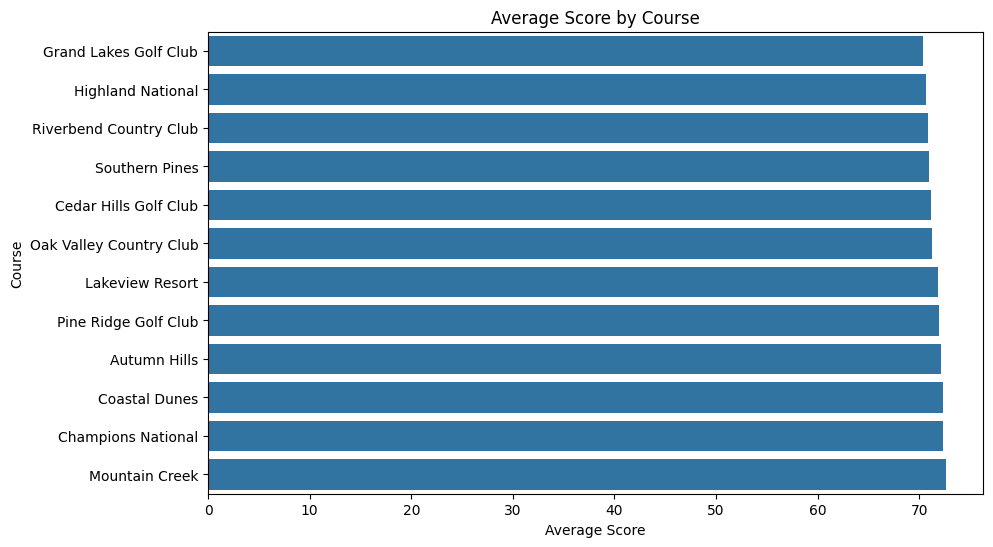

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(data=tournament_summary.sort_values("AverageScore"),
            x="AverageScore",
            y="Course")

plt.title("Average Score by Course")
plt.xlabel("Average Score")
plt.ylabel("Course")
plt.show()

>Average scores vary across courses, but the differences are relatively modest. The highest average is around 71, while most courses are clustered around 72–73. This indicates some variation in scoring difficulty between courses while keeping overall course performance relatively consistent.

### **Earnings Analysis**

#### Earnings vs Score

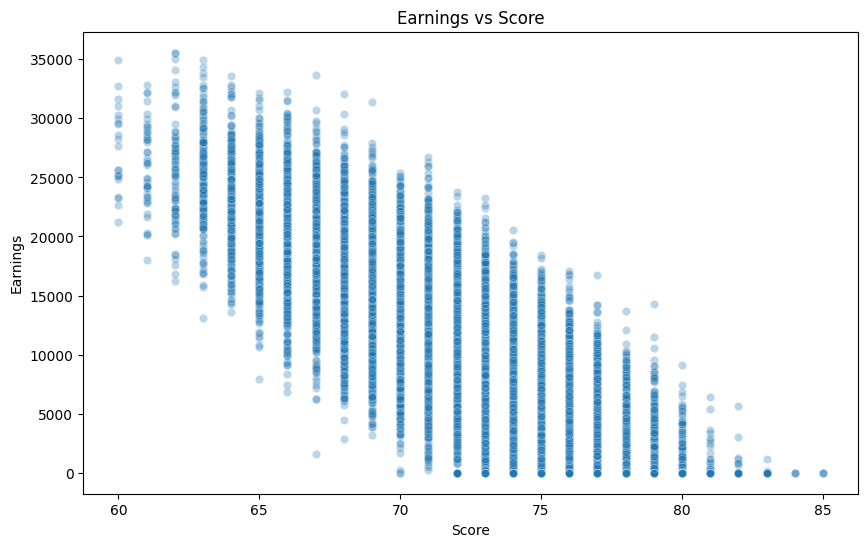

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x="Score",y="Earnings",alpha=0.3)

plt.title("Earnings vs Score")
plt.xlabel("Score")
plt.ylabel("Earnings")
plt.show()


>There is a strong negative relationship between score and earnings. Lower scores are generally associated with higher earnings, while higher scores tend to correspond with substantially lower earnings. This is consistent with the structure of competitive golf, where stronger performance generally produces greater financial rewards.

In [34]:
df["Earnings"].describe()

,Earnings
count,25000.000000
mean,11646.325822
std,6499.214142
min,0.000000
25%,6931.352500
50%,11545.855000
75%,16064.747500
max,35555.350000


#### Top Earners

In [35]:
top_earners = (
    player_summary
    .sort_values("TotalEarnings", ascending=False)
    .head(10)
)

top_earners[["FirstName","LastName","TotalEarnings",
            "AverageScore","AverageStrokesGained"]]

,FirstName,LastName,TotalEarnings,AverageScore,AverageStrokesGained
478,Mason,Davis,1258863.59,64.269231,3.082885
179,Luke,Anderson,1213826.53,65.153846,3.097500
209,Jamie,Jackson,1200723.61,64.880000,3.094800
220,Alex,White,1195463.39,64.886792,2.804906
113,Blake,Wilson,1179640.94,65.176471,3.243725
125,Drew,Moore,1134027.07,65.220000,2.956000
252,Logan,Harris,1120674.32,64.734694,2.711837
284,Cameron,Thompson,1102251.11,65.647059,2.741569
323,Morgan,Martinez,1096722.42,65.820000,2.833600
460,Alex,Davis,1087811.61,65.788462,2.451923


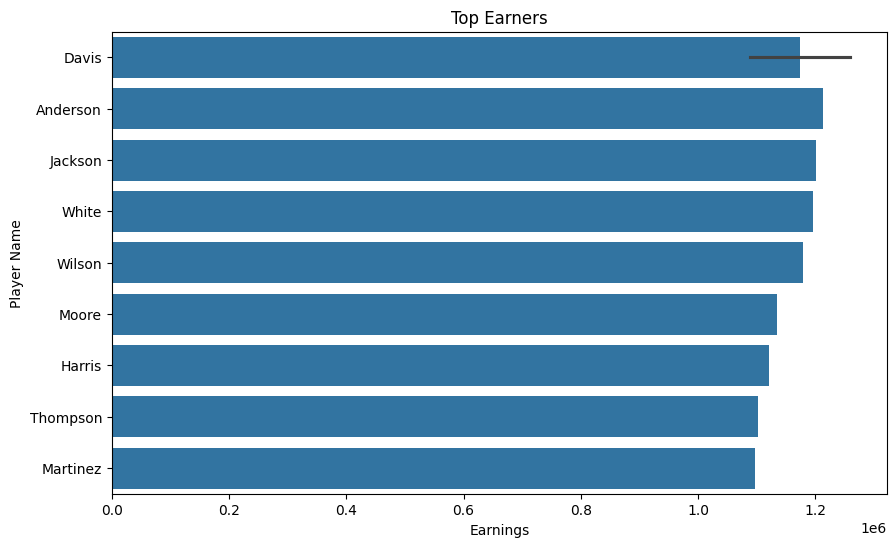

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(data=top_earners,x="TotalEarnings",y="LastName")

plt.title("Top Earners")
plt.xlabel("Earnings")
plt.ylabel("Player Name")
plt.show()

>The highest-earning players generated roughly 1.1–1.25 million dollars in total earnings, with relatively small differences among several of the top earners. This indicates that sustained strong performance across tournaments can produce substantial differences in cumulative earnings.

### **Correlation Analysis**

In [37]:
corr_columns = [
    "Age",
    "DriveDistance",
    "FairwaysHit",
    "GIR",
    "Putts",
    "Birdies",
    "Bogeys",
    "Score",
    "StrokesGainedTotal",
    "Earnings"
]

In [38]:
corr_matrix = df[corr_columns].corr()
corr_matrix

,Age,DriveDistance,FairwaysHit,GIR,Putts,Birdies,Bogeys,Score,StrokesGainedTotal,Earnings
Age,1.000000,-0.008658,-0.008533,-0.012958,-0.001931,-0.020593,0.011130,0.020160,-0.014011,-0.019301
DriveDistance,-0.008658,1.000000,0.236176,0.282824,-0.141619,0.317470,-0.311699,-0.399537,0.419300,0.377374
FairwaysHit,-0.008533,0.236176,1.000000,0.248583,-0.113751,0.276811,-0.253995,-0.326459,0.345091,0.303272
GIR,-0.012958,0.282824,0.248583,1.000000,-0.134135,0.524537,-0.504538,-0.656388,0.477117,0.573913
Putts,-0.001931,-0.141619,-0.113751,-0.134135,1.000000,-0.152427,0.155590,0.287136,-0.277902,-0.250146
Birdies,-0.020593,0.317470,0.276811,0.524537,-0.152427,1.000000,-0.397877,-0.616931,0.470374,0.585091
Bogeys,0.011130,-0.311699,-0.253995,-0.504538,0.155590,-0.397877,1.000000,0.603897,-0.464128,-0.562338
Score,0.020160,-0.399537,-0.326459,-0.656388,0.287136,-0.616931,0.603897,1.000000,-0.681085,-0.804449
StrokesGainedTotal,-0.014011,0.419300,0.345091,0.477117,-0.277902,0.470374,-0.464128,-0.681085,1.000000,0.677692
Earnings,-0.019301,0.377374,0.303272,0.573913,-0.250146,0.585091,-0.562338,-0.804449,0.677692,1.000000


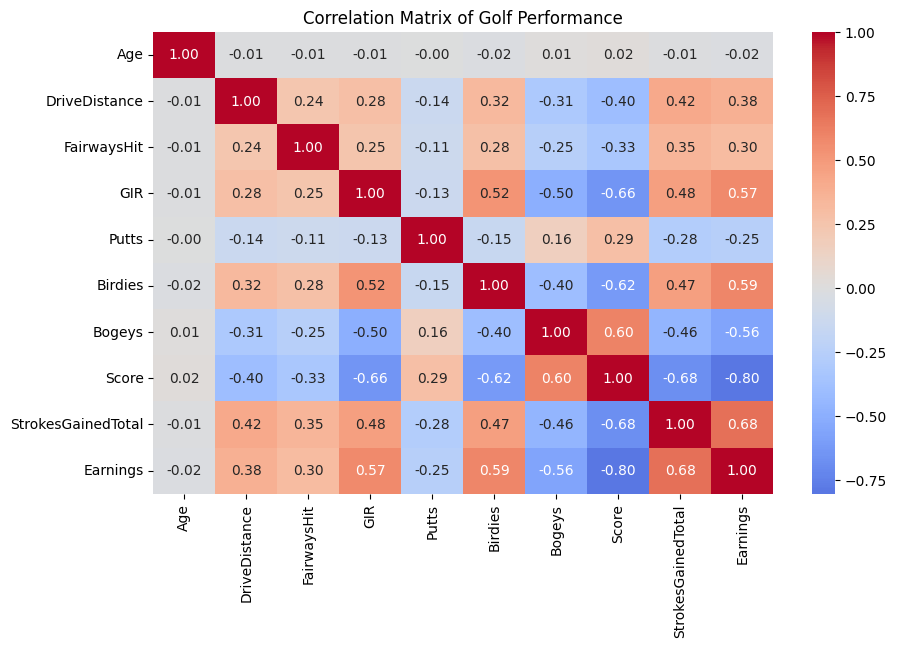

In [39]:
plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix, annot=True,fmt=".2f", cmap="coolwarm",center=0)

plt.title("Correlation Matrix of Golf Performance")
plt.show()

>The correlation matrix identifies several important relationships with score. Strokes Gained (-0.68), GIR (-0.66), Birdies (-0.62), and Bogeys (+0.60) have the strongest relationships with scoring. Driving distance (-0.40) and fairways hit (-0.33) show moderate negative relationships, while putts (+0.29) have a weaker positive relationship

In [40]:
score_corr = (
    corr_matrix["Score"]
    .sort_values()
)

score_corr

,Score
Earnings,-0.804449
StrokesGainedTotal,-0.681085
GIR,-0.656388
Birdies,-0.616931
DriveDistance,-0.399537
FairwaysHit,-0.326459
Age,0.020160
Putts,0.287136
Bogeys,0.603897
Score,1.000000


#### "Top Factors"

In [41]:
score_factors = (
    corr_matrix["Score"]
    .drop("Score")
    .sort_values(key=abs, ascending=False)
    .reset_index()
)

score_factors.columns = ["Variable","CorrelationWithScore"]
score_factors

,Variable,CorrelationWithScore
0,Earnings,-0.804449
1,StrokesGainedTotal,-0.681085
2,GIR,-0.656388
3,Birdies,-0.616931
4,Bogeys,0.603897
5,DriveDistance,-0.399537
6,FairwaysHit,-0.326459
7,Putts,0.287136
8,Age,0.020160


### **Summary**

In [42]:
summary_metrics = pd.DataFrame({
    "Metric": [
        "Average Score",
        "Average Score to Par",
        "Average Driving Distance",
        "Average Fairways Hit",
        "Average GIR",
        "Average Putts",
        "Average Birdies",
        "Average Bogeys",
        "Average Strokes Gained",
        "Average Earnings"
    ],
    "Value": [
        df["Score"].mean(),
        df["ScoreToPar"].mean(),
        df["DriveDistance"].mean(),
        df["FairwaysHit"].mean(),
        df["GIR"].mean(),
        df["Putts"].mean(),
        df["Birdies"].mean(),
        df["Bogeys"].mean(),
        df["StrokesGainedTotal"].mean(),
        df["Earnings"].mean()
    ]
})

summary_metrics

,Metric,Value
0,Average Score,71.529400
1,Average Score to Par,0.195920
2,Average Driving Distance,295.246208
3,Average Fairways Hit,8.993000
4,Average GIR,12.012480
5,Average Putts,30.000040
6,Average Birdies,4.022440
7,Average Bogeys,3.000600
8,Average Strokes Gained,-0.000503
9,Average Earnings,11646.325822


### **Key Findings**



1. Scoring Performance<br>
>Overall scores were concentrated around 72–73 strokes, with most rounds falling between approximately 68 and 76. Score-to-par results were centered near even par, showing a broad range of performance from well under par to significantly over par. The relatively narrow range among the top 10 players also indicates that high-performing players had fairly similar scoring averages.


2. Driving<br>
>Driving distance had a moderate negative correlation with score (-0.40), indicating that longer drives were generally associated with lower scores. Fairways hit also had a negative relationship with score (-0.33), suggesting that greater driving accuracy was associated with improved scoring. However, the scatter and boxplots show considerable variation, indicating that driving performance alone does not explain overall scoring.


3. Putting<br>
>Putts had a positive correlation with score (0.29), meaning that rounds with more putts generally resulted in higher scores. However, the relationship was weaker than several other performance metrics, suggesting that putting was associated with scoring but had less of a relationship with score than factors such as GIR, birdies, bogeys, and strokes gained.


4. Greens in Regulation<br>
>GIR had a strong negative correlation with score (-0.66). The analysis also showed a consistent decrease in average score as GIR increased, with average scores falling from approximately 77.5 strokes in the lowest GIR group to approximately 67 strokes in the highest group. This makes GIR one of the strongest observed performance variables associated with scoring.


5. Birdies and Bogeys<br>
>Birdies had a strong negative correlation with score (-0.62), while bogeys had a strong positive correlation (0.60). The boxplots showed that rounds with more birdies generally produced lower scores, while rounds with more bogeys produced higher scores. The birdie-bogey balance also showed a strong negative relationship with score, indicating that producing more birdies relative to bogeys was associated with lower scores.



6. Strokes Gained<br>
>Strokes Gained Total had the strongest negative correlation with score among the individual performance metrics (-0.68). The scatterplot shows a clear downward trend, with higher strokes-gained values generally corresponding to lower scores. This indicates a strong association between overall strokes-gained performance and scoring within the dataset.



7. Tournament Performance<br>
>Average scores varied across the 12 courses, but the differences were relatively modest, with course averages generally clustered around the low 70s. The results indicate that course selection and course characteristics contributed to some variation in scoring, although player performance metrics showed larger relationships with individual scores.



8. Earnings<br>
>Earnings had a strong negative correlation with score (-0.80), meaning lower scores were strongly associated with higher earnings in the dataset. The earnings analysis also showed that the highest-earning players accumulated more than $1 million across the season. This suggests a strong relationship between scoring performance and financial outcomes within the simulated tournament structure.



### **Phase 2 Conclusion**

Exploratory analysis identified several important relationships within the
golf performance dataset.

The analysis examined player performance, scoring, driving, putting, greens
in regulation, birdies, bogeys, strokes gained, tournament performance, and
earnings.

The strongest relationships with scoring will be used to guide the next
phases of the project. These findings will inform the SQL analysis, dashboard
development, and predictive modeling portions of the project.

The dataset is now sufficiently understood to proceed to Phase 3:
SQL Analysis.